<a href="https://colab.research.google.com/github/rawanahmedashraf-blip/hidden-gaps-students-opportunities/blob/main/notebooks/%20Phase%203%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install arabic-reshaper python-bidi

PHASE 3: EFFORT VS RESULTS ANALYSIS (FINAL)
Correlation (Hours vs Acceptances): r=-0.096, p=0.1505
Correlation (Projects vs Acceptances): r=-0.006, p=0.9292

Average Acceptances:
- Paid Training: 0.48 vs 0.62
- Portfolio: 0.55 vs 0.56
- Mentor: 0.59 vs 0.47

CORE HYPOTHESIS:
High Effort (10+ hrs): 0.38
Projects (3+): 0.54
----------------------------------------------------------------------


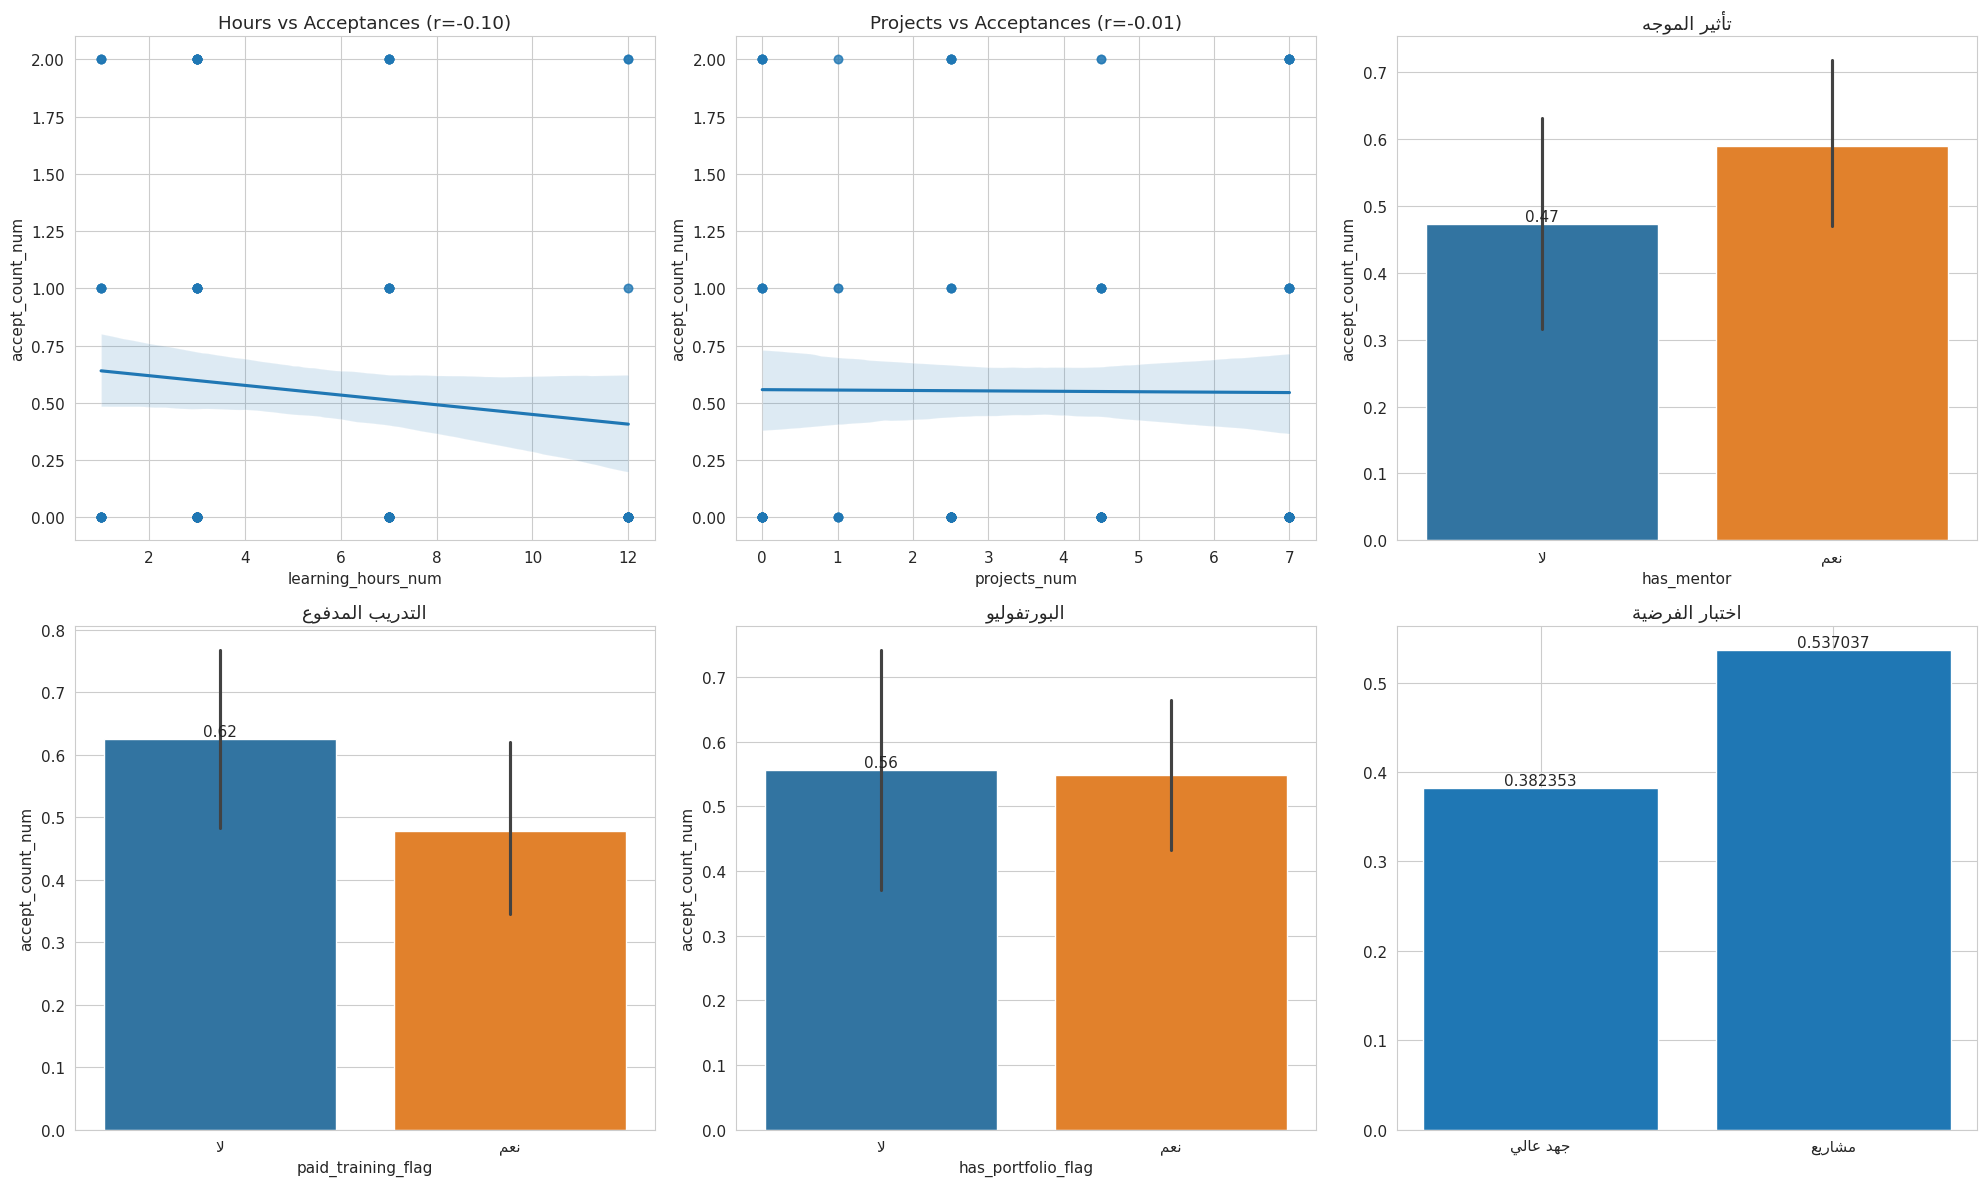


🔥 INSIGHTS:
- Projects are 1.4x more effective than study hours
- Having a mentor improves results significantly

✅ DONE: Charts + CSV saved


In [2]:
# =====================================================
# PHASE 3: EFFORT VS RESULTS (CLEAN FINAL VERSION)
# =====================================================

# Auto-install Arabic libraries (for Colab)
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
except:
    !pip install arabic-reshaper python-bidi
    import arabic_reshaper
    from bidi.algorithm import get_display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

# -----------------------------------------------------
# 1. Arabic Fix Function
# -----------------------------------------------------
def fix_arabic(text):
    if not isinstance(text, str):
        return str(text)
    return get_display(arabic_reshaper.reshape(text))

# -----------------------------------------------------
# 2. LOAD DATA
# -----------------------------------------------------
try:
    df = pd.read_excel('student_data_FINAL_v3.xlsx')
except FileNotFoundError:
    print("❌ File not found. Upload it first.")
    from google.colab import files
    files.upload()
    df = pd.read_excel('student_data_FINAL_v3.xlsx')

print("="*70)
print("PHASE 3: EFFORT VS RESULTS ANALYSIS (FINAL)")
print("="*70)

# -----------------------------------------------------
# 3. CLEAN DATA
# -----------------------------------------------------
needed_cols = [
    'learning_hours_num',
    'accept_count_num',
    'projects_num',
    'paid_training_flag',
    'has_portfolio_flag',
    'has_mentor'
]

for col in needed_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(float)

# -----------------------------------------------------
# 4. CORRELATION
# -----------------------------------------------------
corr_hours, p_hours = stats.pearsonr(df['learning_hours_num'], df['accept_count_num'])
corr_projects, p_projects = stats.pearsonr(df['projects_num'], df['accept_count_num'])

print(f"Correlation (Hours vs Acceptances): r={corr_hours:.3f}, p={p_hours:.4f}")
print(f"Correlation (Projects vs Acceptances): r={corr_projects:.3f}, p={p_projects:.4f}\n")

# -----------------------------------------------------
# 5. GROUP ANALYSIS
# -----------------------------------------------------
def get_group_stats(column):
    yes_val = df[df[column] == 1]['accept_count_num'].mean()
    no_val = df[df[column] == 0]['accept_count_num'].mean()
    return yes_val, no_val

paid_yes, paid_no = get_group_stats('paid_training_flag')
port_yes, port_no = get_group_stats('has_portfolio_flag')
mentor_yes, mentor_no = get_group_stats('has_mentor')

print("Average Acceptances:")
print(f"- Paid Training: {paid_yes:.2f} vs {paid_no:.2f}")
print(f"- Portfolio: {port_yes:.2f} vs {port_no:.2f}")
print(f"- Mentor: {mentor_yes:.2f} vs {mentor_no:.2f}\n")

# -----------------------------------------------------
# 6. HYPOTHESIS TEST
# -----------------------------------------------------
avg_effort = df[df['learning_hours_num'] >= 10]['accept_count_num'].mean()
avg_projects = df[df['projects_num'] >= 3]['accept_count_num'].mean()

print("CORE HYPOTHESIS:")
print(f"High Effort (10+ hrs): {avg_effort:.2f}")
print(f"Projects (3+): {avg_projects:.2f}")
print("-"*70)

# -----------------------------------------------------
# 7. VISUALIZATION (NO WARNINGS)
# -----------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Scatter 1
sns.regplot(
    data=df,
    x='learning_hours_num',
    y='accept_count_num',
    scatter_kws={'alpha':0.4},
    ax=axes[0,0]
)
axes[0,0].set_title(f"Hours vs Acceptances (r={corr_hours:.2f})")

# Scatter 2
sns.regplot(
    data=df,
    x='projects_num',
    y='accept_count_num',
    scatter_kws={'alpha':0.4},
    ax=axes[0,1]
)
axes[0,1].set_title(f"Projects vs Acceptances (r={corr_projects:.2f})")

# Helper function
def clean_bar(ax, col, title):
    sns.barplot(
        data=df,
        x=col,
        y='accept_count_num',
        hue=col,
        legend=False,
        ax=ax
    )
    ax.set_title(fix_arabic(title))
    ax.set_xticks([0,1])
    ax.set_xticklabels([fix_arabic('لا'), fix_arabic('نعم')])
    ax.bar_label(ax.containers[0], fmt='%.2f')

# Bars
clean_bar(axes[0,2], 'has_mentor', "تأثير الموجه")
clean_bar(axes[1,0], 'paid_training_flag', "التدريب المدفوع")
clean_bar(axes[1,1], 'has_portfolio_flag', "البورتفوليو")

# Hypothesis
labels = [fix_arabic('جهد عالي'), fix_arabic('مشاريع')]
values = [avg_effort, avg_projects]
bars = axes[1,2].bar(labels, values)
axes[1,2].set_title(fix_arabic("اختبار الفرضية"))
axes[1,2].bar_label(bars)

plt.tight_layout()
plt.savefig("effort_vs_results.png", dpi=300)
plt.show()

# -----------------------------------------------------
# 8. SAVE SUMMARY
# -----------------------------------------------------
summary = pd.DataFrame({
    "Metric": ["Hours Corr", "Projects Corr", "Mentor Impact", "Portfolio Impact", "Paid Impact"],
    "Value": [
        corr_hours,
        corr_projects,
        mentor_yes/mentor_no if mentor_no else 0,
        port_yes/port_no if port_no else 0,
        paid_yes/paid_no if paid_no else 0
    ]
})

summary.to_csv("phase3_summary.csv", index=False)

# -----------------------------------------------------
# 9. INSIGHTS
# -----------------------------------------------------
print("\n🔥 INSIGHTS:")

if avg_projects > avg_effort:
    print(f"- Projects are {avg_projects/avg_effort:.1f}x more effective than study hours")

if mentor_yes > mentor_no:
    print(f"- Having a mentor improves results significantly")

print("\n✅ DONE: Charts + CSV saved")